In [1]:
with open('input.txt', 'r', encoding= 'utf-8') as f:
    text = f.read()

In [2]:
print(len(text))
type(text)

1115394


str

In [3]:
chars = sorted(set(list(text)))
vocab_size = len(chars)
print(''.join(chars))
print(vocab_size)


 !$&',-.3:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz
65


In [4]:
print(chars)

['\n', ' ', '!', '$', '&', "'", ',', '-', '.', '3', ':', ';', '?', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']


In [5]:
stoi = {ch:i for i,ch in enumerate(chars)} # 
itos = {i:ch for i,ch in enumerate(chars)}
encode =  lambda s: [stoi[c] for c in s]
decode =  lambda l: [itos[i] for i in l]

print(encode("Hello world"))


[20, 43, 50, 50, 53, 1, 61, 53, 56, 50, 42]


In [6]:
print(encode("Hello world"))
print(''.join(decode(encode("Hello world"))))


[20, 43, 50, 50, 53, 1, 61, 53, 56, 50, 42]
Hello world


In [7]:
import torch
data = torch.tensor(encode(text), dtype=torch.long) # this long type here make it so that it's a whole numebr 1,2,3 instead of 1.1,2.5

In [8]:
n = int(0.9 * len(data))
train_data = data[:n] 
val_data = data[n:] 

In [9]:
print(len(train_data))
print(len(val_data))

1003854
111540


In [10]:
block_size = 8 
train_data[:block_size+1]

tensor([18, 47, 56, 57, 58,  1, 15, 47, 58])

In [11]:

x = train_data[:block_size]
y = train_data[1:block_size+1]

for t in range(block_size):
    context = x[:t+1] # The + 1 is is when t = 0, we splice nothing which result in y[0] = 47, x = []
    target = y[t]
    print(f"when input is {context} the target: {target}")


when input is tensor([18]) the target: 47
when input is tensor([18, 47]) the target: 56
when input is tensor([18, 47, 56]) the target: 57
when input is tensor([18, 47, 56, 57]) the target: 58
when input is tensor([18, 47, 56, 57, 58]) the target: 1
when input is tensor([18, 47, 56, 57, 58,  1]) the target: 15
when input is tensor([18, 47, 56, 57, 58,  1, 15]) the target: 47
when input is tensor([18, 47, 56, 57, 58,  1, 15, 47]) the target: 58


In [12]:
print(x[0])

tensor(18)


In [13]:
torch.manual_seed(1337)
batch_size = 4
block_size = 8 

def get_batch(split):
    data = train_data if split == "train" else val_data
    ix = torch.randint(len(data) - block_size, (batch_size,))
    x = torch.stack([data[i:i+block_size] for i in ix])
    y = torch.stack([data[i+1: i+1+block_size] for i in ix])
    return x,y

xb,yb = get_batch('train')


In [14]:
print('inputs:')
print(xb.shape)
print(xb)
print('targets:')
print(yb.shape)
print(yb)

print('----')


inputs:
torch.Size([4, 8])
tensor([[24, 43, 58,  5, 57,  1, 46, 43],
        [44, 53, 56,  1, 58, 46, 39, 58],
        [52, 58,  1, 58, 46, 39, 58,  1],
        [25, 17, 27, 10,  0, 21,  1, 54]])
targets:
torch.Size([4, 8])
tensor([[43, 58,  5, 57,  1, 46, 43, 39],
        [53, 56,  1, 58, 46, 39, 58,  1],
        [58,  1, 58, 46, 39, 58,  1, 46],
        [17, 27, 10,  0, 21,  1, 54, 39]])
----


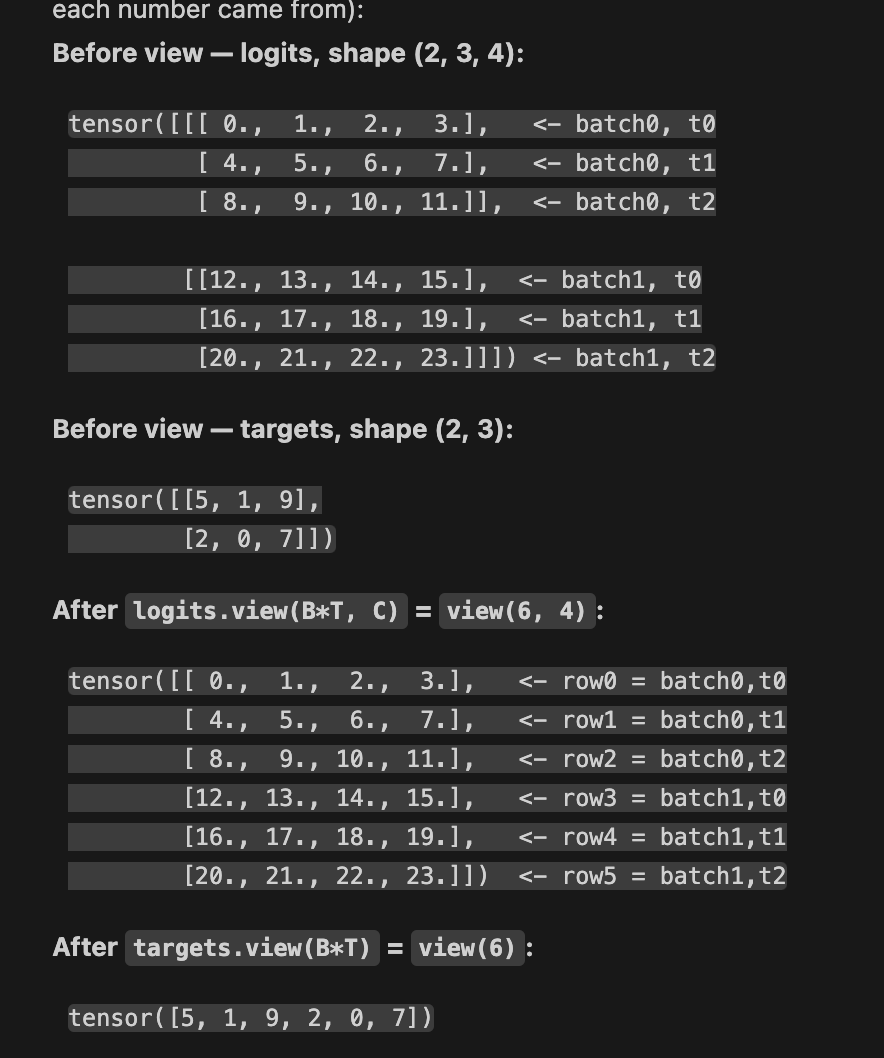

In [15]:
from sympy import N
import torch
import torch.nn as nn 
from torch.nn import functional as F 

class BigramLanguageModel(nn.Module):

    def __init__(self, vocab_size):
        super().__init__()

        self.token_embedding_table = nn.Embedding(vocab_size,vocab_size)
    
# B batch 4 
# T blocksize = 8
# C the dimension which would be 65 a,b,c,A,B,C,!,@,# ...

    def forward(self,idx,targets = None):

        logits = self.token_embedding_table(idx)
        B,T,C = logits.shape

        if targets is None:
            loss = None
        
        else : 
            logits = logits.view(B*T, C)
            targets = targets.view(B*T)
            loss = F.cross_entropy(logits, targets)

        # cross_entropy The way I understand this
        # counts_sum = counts.sum(dim=1, keepdim=True)
        # probs = counts / counts_sum

  
        # logprobs = probs.log()
        # loss = -logprobs[torch.arange(N), targets].mean()

        return logits,loss

    def generate(self,idx,max_new_tokens): # current context of some character idx
        for _ in range(max_new_tokens):
            
            logits, loss = self.forward(idx)
            logits = logits[:,-1,:] # becomes B,C
            probs = F.softmax(logits, dim=-1) 
            # softmax(x_i) = exp(x_i) / sum_j( exp(x_j) )
            idx_next = torch.multinomial(probs, num_samples=1) # (B, 1)
            idx = torch.cat((idx, idx_next), dim = 1 ) # (B, T+1)
             
        return idx
            
            
            
m = BigramLanguageModel(vocab_size)
logits,loss = m(xb,yb)
print(logits.shape)
print(loss)

torch.Size([32, 65])
tensor(5.0364, grad_fn=<NllLossBackward0>)


In [16]:
idx = torch.zeros((1,1), dtype= torch.long)

print(''.join((decode(m.generate(idx = torch.zeros((1,1), dtype= torch.long), max_new_tokens= 100)[0].tolist()))))


lfJeukRuaRJKXAYtXzfJ:HEPiu--sDioi;ILCo3pHNTmDwJsfheKRxZCFs
lZJ XQc?:s:HEzEnXalEPklcPU cL'DpdLCafBheH


In [17]:
optimizer = torch.optim.Adam(m.parameters(),lr=1e-3) # 1 * 10**-3



In [18]:
for steps in range(10000):
    
    xb, yb = get_batch('train')
    
    logits, loss = m.forward(xb, yb)
    optimizer.zero_grad(set_to_none=True) 
    loss.backward()
    
    optimizer.step()
    
    print(loss.item())
    

4.873950481414795
4.714165687561035
4.440373420715332
4.961308002471924
4.5760579109191895
4.620034217834473
4.439950466156006
4.543165683746338
4.36994743347168
4.560135364532471
4.903951168060303
4.842033386230469
4.526835918426514
4.8907790184021
4.806990146636963
4.829017162322998
4.339177131652832
4.553744316101074
4.747852325439453
4.5345139503479
4.823821544647217
4.9684977531433105
4.901899337768555
4.798932075500488
4.6801252365112305
4.511504173278809
4.890913963317871
4.824678421020508
4.626321315765381
4.619579315185547
4.412992477416992
4.8929243087768555
4.701543807983398
4.7019243240356445
4.54451322555542
4.3223958015441895
4.718767166137695
5.002787113189697
4.582093238830566
4.686124324798584
4.686014652252197
4.553405284881592
4.588379859924316
4.817134380340576
4.703028202056885
4.575076580047607
4.940161228179932
4.394619941711426
4.920438766479492
4.813542366027832
4.398862838745117
4.33344841003418
4.713379859924316
4.853452682495117
4.58834981918335
4.6082324981

In [19]:
torch.manual_seed(42)

a = torch.ones((3,3))
b = torch.tril(a) # tril is just transforming it to a triangular matrix 
b = b/torch.sum(b, dim = 1, keepdim= True) # the keep dim = 1, we won't speeze it  
x = torch.randint(0,10,(3,2)).float()


c = b @ x
# print(a)
# print(b)
# print(x)
# print(c)

# print(x)


In [20]:
B,T,C = 4,8,2

wei = torch.tril(torch.ones(T,T)) # 8 * 8 

wei = wei/wei.sum(1,keepdim=True)


In [21]:
X = torch.randint(0,10,(B,T,C), dtype= torch.float32)
xbow2 = wei @ X 

# wei is 8x8 and X is B,T,C which doesn't wokr 
# we need wei to be B,8,8 which is B,T,T
# The way the matrix work would be after matching the B of wei and X
# (T,T) @ (T,C) = (T,C) => 8,2 (shape) 

# but due to the broadcasting rule this will allow for the matrix interaction



In [22]:
torch.manual_seed(1337)
B,T,C = 4,8,32
x = torch.rand(B,T,C)

tril = torch.tril(torch.ones(T,T))
wei = torch.zeros((T,T))
wei = wei.masked_fill(tril ==0, float('-inf'))
wei = F.softmax(wei, dim = -1 )
out = wei 
wei 

tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5000, 0.5000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3333, 0.3333, 0.3333, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2500, 0.2500, 0.2500, 0.2500, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2000, 0.2000, 0.2000, 0.2000, 0.2000, 0.0000, 0.0000, 0.0000],
        [0.1667, 0.1667, 0.1667, 0.1667, 0.1667, 0.1667, 0.0000, 0.0000],
        [0.1429, 0.1429, 0.1429, 0.1429, 0.1429, 0.1429, 0.1429, 0.0000],
        [0.1250, 0.1250, 0.1250, 0.1250, 0.1250, 0.1250, 0.1250, 0.1250]])

In [25]:
B,T,C = 4,8,32
x = torch.rand(B,T,C)

head_size = 16
key = nn.Linear(C,head_size,bias=False) 
query = nn.Linear(C,head_size, bias =False)
value  = nn.Linear(C,head_size, bias =False) 
k = key(x) # B T 16
q = query(x) # B T 16 

weight = q @ k.transpose(-2,-1)  # or the affinity
# B T 16 @ B 16 T   - > (B,T,T)

tril = torch.tril(torch.ones(T,T))

# tril = traingular matrices
# ones to fill em with one
v = value(x)
wei = wei.masked_fill(tril == 0, float('-inf'))
wei = F.softmax(wei,dim = -1)
out = wei @ v 

out.shape

torch.Size([4, 8, 16])

In [25]:
wei

tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5000, 0.5000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3333, 0.3333, 0.3333, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2500, 0.2500, 0.2500, 0.2500, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2000, 0.2000, 0.2000, 0.2000, 0.2000, 0.0000, 0.0000, 0.0000],
        [0.1667, 0.1667, 0.1667, 0.1667, 0.1667, 0.1667, 0.0000, 0.0000],
        [0.1429, 0.1429, 0.1429, 0.1429, 0.1429, 0.1429, 0.1429, 0.0000],
        [0.1250, 0.1250, 0.1250, 0.1250, 0.1250, 0.1250, 0.1250, 0.1250]])